In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
df = pd.read_csv("HistoricalQuotes.csv")
df.info

<bound method DataFrame.info of             date      close     volume       open       high        low
0     02/28/2020    $273.36  106721200    $257.26    $278.41    $256.37
1     02/27/2020    $273.52   80151380     $281.1       $286    $272.96
2     02/26/2020    $292.65   49678430    $286.53    $297.88     $286.5
3     02/25/2020    $288.08   57668360    $300.95    $302.53    $286.13
4     02/24/2020    $298.18   55548830    $297.26    $304.18    $289.23
...          ...        ...        ...        ...        ...        ...
2513  03-05-2010   $31.2786  224647427   $30.7057   $31.3857   $30.6614
2514  03-04-2010   $30.1014   89591907   $29.8971   $30.1314   $29.8043
2515  03-03-2010   $29.9043   92846488   $29.8486   $29.9814   $29.7057
2516  03-02-2010   $29.8357  141486282     $29.99   $30.1186   $29.6771
2517  03-01-2010   $29.8557  137312041   $29.3928   $29.9286     $29.35

[2518 rows x 6 columns]>

In [3]:
df.columns = [col.strip().lower() for col in df.columns]

df.rename(columns={
    'close/last': 'close',
    'close last': 'close'
}, inplace=True)

df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['date'])
df = df.sort_values('date').reset_index(drop=True)

for col in ['close', 'open', 'high', 'low']:
    if col in df.columns:
        df[col] = df[col].astype(str).replace('[\$,]', '', regex=True).astype(float)

df.set_index('date', inplace=True)

TARGET_COL = 'close'

In [4]:
df = df.asfreq('D')
df[TARGET_COL] = df[TARGET_COL].fillna(method='ffill')

C:\Users\vsaur\AppData\Local\Temp\ipykernel_46784\44720923.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[TARGET_COL] = df[TARGET_COL].fillna(method='ffill')


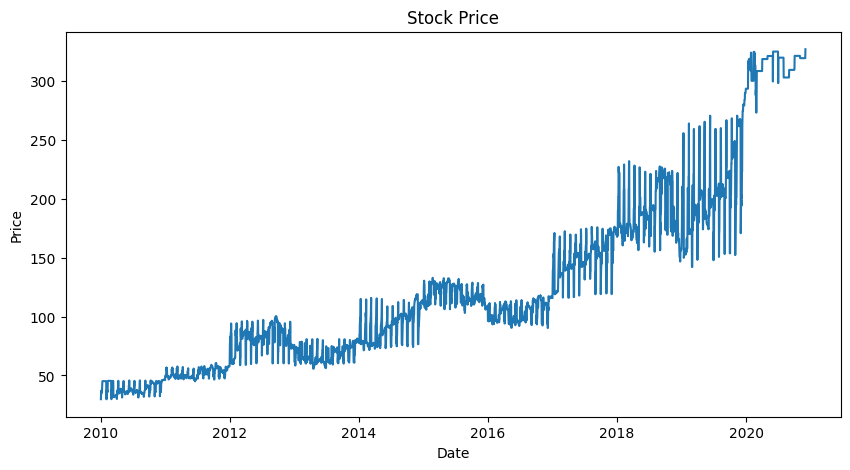

In [5]:
# ================== ORIGINAL DATA PLOT ==================
plt.figure(figsize=(10,5))
plt.plot(df[TARGET_COL])
plt.title("Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
# ================== STATIONARITY TEST ==================
result = adfuller(df[TARGET_COL])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# ================== MAKE STATIONARY ==================
df['diff'] = df[TARGET_COL].diff()

ADF Statistic: 2.076454257804159
p-value: 0.9987644219447378


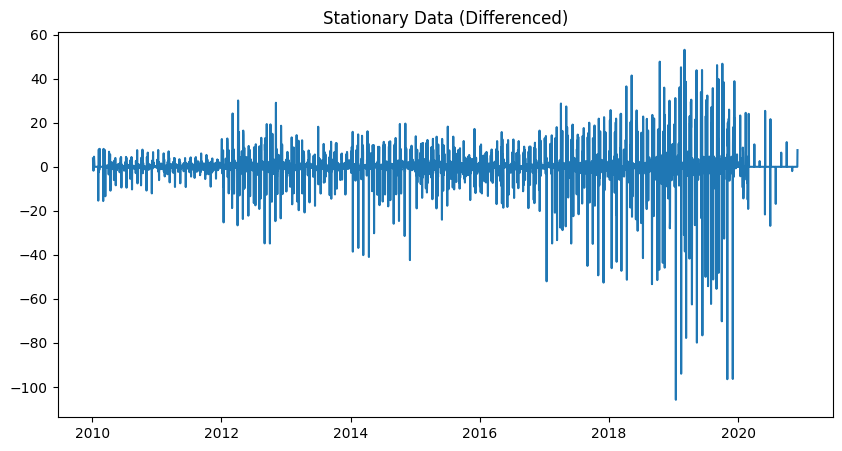

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df['diff'])
plt.title("Stationary Data (Differenced)")
plt.show()

In [8]:
result_diff = adfuller(df['diff'].dropna())
print("ADF after differencing:", result_diff[0])
print("p-value after differencing:", result_diff[1])

ADF after differencing: -17.317096738609614
p-value after differencing: 5.509867382934401e-30


<Figure size 1000x500 with 0 Axes>

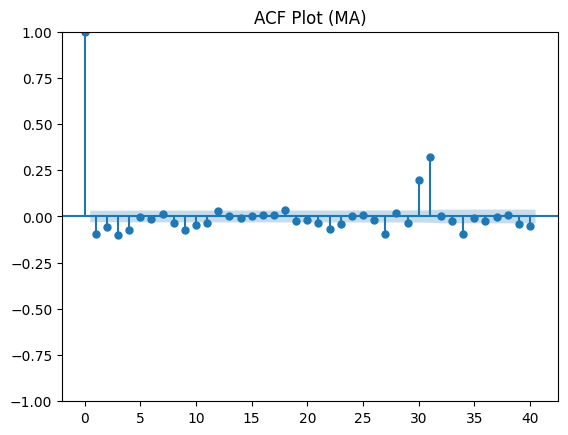

In [9]:
# ================== ACF ==================
plt.figure(figsize=(10,5))
plot_acf(df['diff'].dropna(), lags=40)
plt.title("ACF Plot (MA)")
plt.show()

<Figure size 1000x500 with 0 Axes>

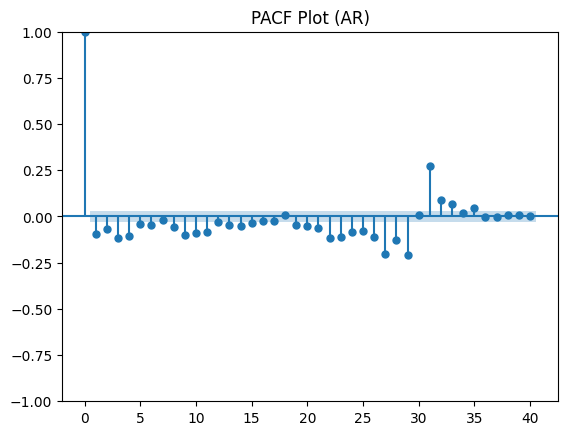

In [10]:
# ================== PACF ==================
plt.figure(figsize=(10,5))
plot_pacf(df['diff'].dropna(), lags=40)
plt.title("PACF Plot (AR)")
plt.show()

In [11]:
# ================== TRAIN TEST SPLIT ==================
train_size = int(len(df) * 0.8)
train_data = df[TARGET_COL][:train_size]
test_data = df[TARGET_COL][train_size:]

In [12]:
# ================== ARIMA ==================
model_arima = ARIMA(train_data, order=(5,1,0))
model_fit = model_arima.fit()

# SUMMARY
print(model_fit.summary())

# FORECAST
forecast_arima = model_fit.forecast(steps=len(test_data))

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 3189
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -10372.961
Date:                Mon, 04 May 2026   AIC                          20757.922
Time:                        21:53:56   BIC                          20794.325
Sample:                    01-03-2010   HQIC                         20770.976
                         - 09-26-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1152      0.014     -8.220      0.000      -0.143      -0.088
ar.L2         -0.0973      0.013     -7.505      0.000      -0.123      -0.072
ar.L3         -0.1062      0.010    -10.127      0.0

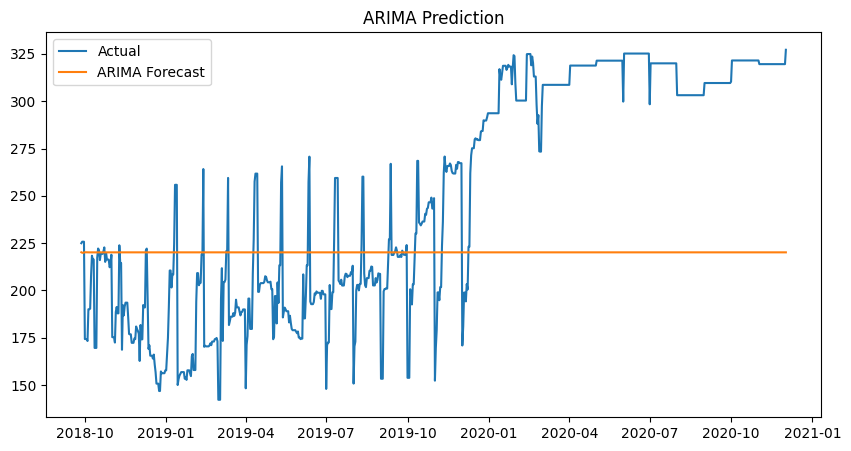

In [13]:
# ================== ARIMA PLOT ==================
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Actual")
plt.plot(test_data.index, forecast_arima, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Prediction")
plt.show()

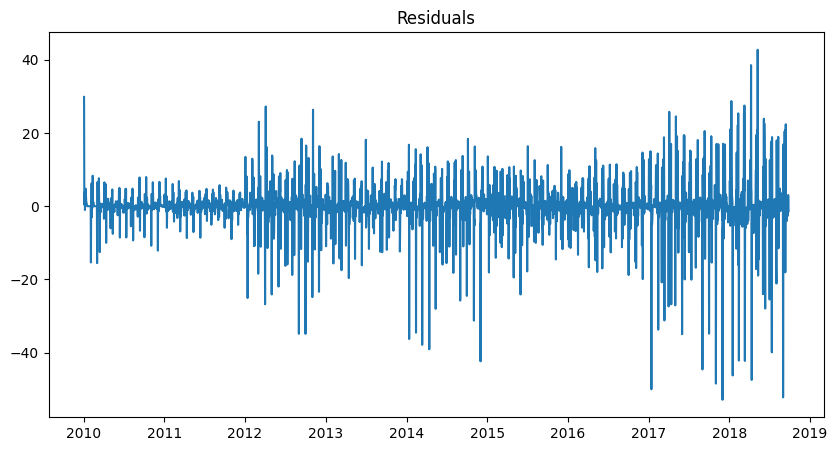

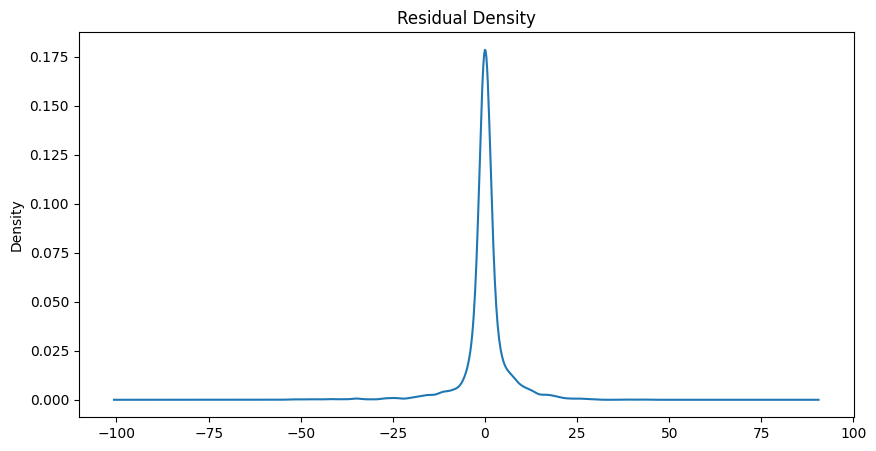

In [14]:
# ================== RESIDUAL ANALYSIS ==================
residuals = model_fit.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(10,5))
residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()

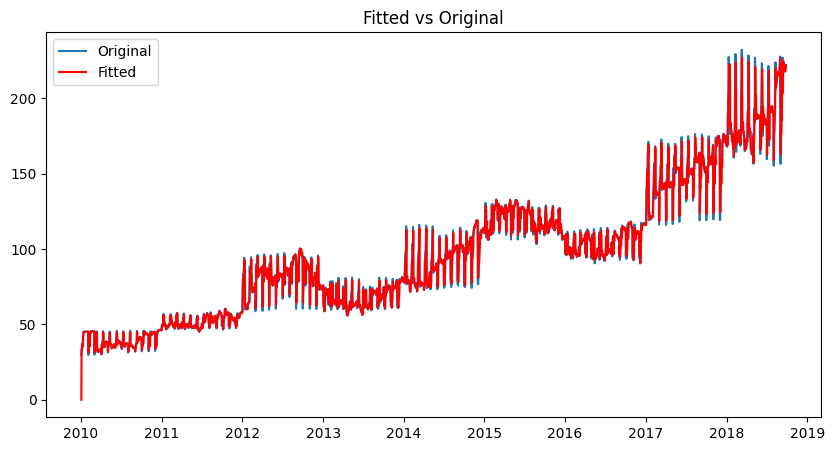

In [15]:
# ================== FITTED VALUES ==================
fitted = model_fit.fittedvalues

plt.figure(figsize=(10,5))
plt.plot(train_data, label="Original")
plt.plot(fitted, color='red', label="Fitted")
plt.legend()
plt.title("Fitted vs Original")
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[[TARGET_COL]])

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

train_size_lstm = int(len(X) * 0.8)

X_train, X_test = X[:train_size_lstm], X[train_size_lstm:]
y_train, y_test = y[:train_size_lstm], y[train_size_lstm:]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [17]:
# ================== LSTM MODEL ==================
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50


C:\Users\vsaur\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0040
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0016
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0016
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0015
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0015
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0015
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0014
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0014
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0012
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0012
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0011
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0011
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0010
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0011
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 9.9625e-04
Epoch 16/50

In [18]:
# ================== LSTM PREDICT ==================
predictions = model_lstm.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# ================== EVALUATION ==================
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print("LSTM RMSE:", rmse)
print("LSTM MAE:", mae)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
LSTM RMSE: 15.499524002245282
LSTM MAE: 11.365206327559692


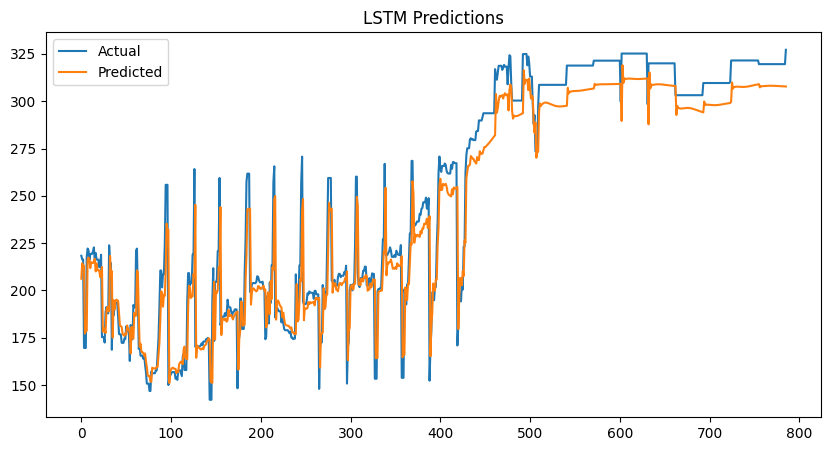

In [19]:
# ================== LSTM PLOT ==================
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM Predictions")
plt.show()

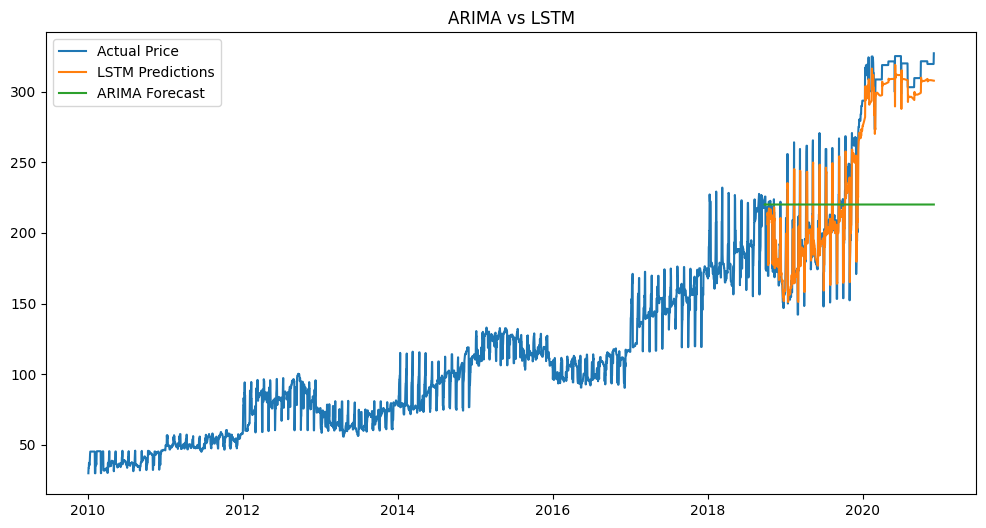

In [20]:
# ================== FINAL COMPARISON ==================
pred_plot = np.empty(len(df))
pred_plot[:] = np.nan
pred_plot[-len(predictions):] = predictions.flatten()

plt.figure(figsize=(12,6))
plt.plot(df[TARGET_COL], label="Actual Price")
plt.plot(df.index, pred_plot, label="LSTM Predictions")
plt.plot(test_data.index, forecast_arima, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA vs LSTM")
plt.show()


===== WEIGHTED HYBRID RESULTS =====
Weight 0.0 → RMSE: 68.3514
Weight 0.1 → RMSE: 62.4695
Weight 0.2 → RMSE: 56.6171
Weight 0.3 → RMSE: 50.8040
Weight 0.4 → RMSE: 45.0457
Weight 0.5 → RMSE: 39.3662
Weight 0.6 → RMSE: 33.8051
Weight 0.7 → RMSE: 28.4320
Weight 0.8 → RMSE: 23.3771
Weight 0.9 → RMSE: 18.8973

Best Weight (LSTM contribution): 0.9

===== FINAL COMPARISON =====
ARIMA  -> RMSE: 68.3514, MAE: 58.6805
LSTM   -> RMSE: 15.4995, MAE: 11.3652
HYBRID -> RMSE: 18.8973, MAE: 15.2375


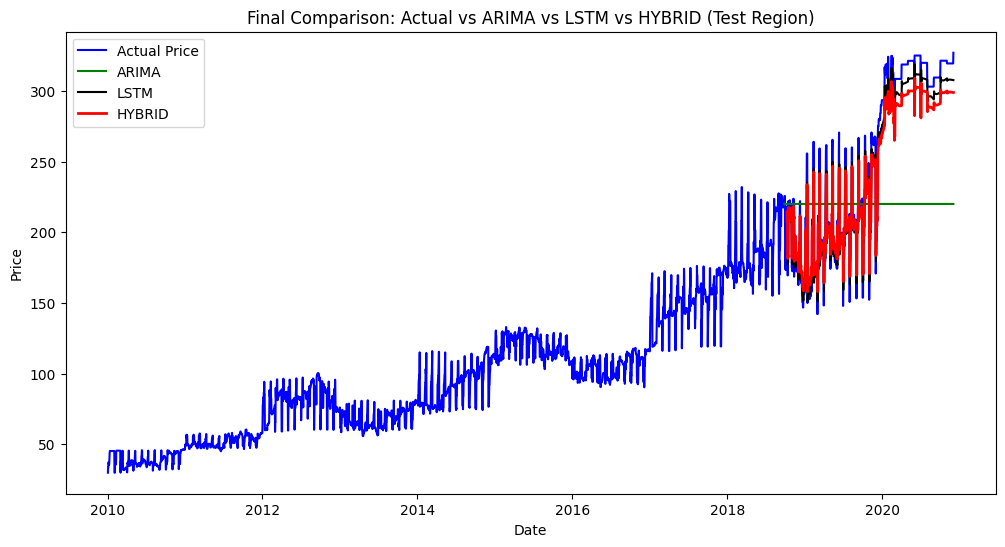

In [21]:
# ================== ALIGN DATA ==================
min_len = min(len(predictions), len(forecast_arima))

arima_vals = forecast_arima[-min_len:].values
lstm_vals = predictions.flatten()[-min_len:]
actual_vals = y_test_actual.flatten()[-min_len:]

# ================== FIND BEST WEIGHT ==================
weights = np.arange(0, 1.0, 0.1)

best_rmse = float("inf")
best_weight = None
best_hybrid = None

print("\n===== WEIGHTED HYBRID RESULTS =====")

for w in weights:
    hybrid = w * lstm_vals + (1 - w) * arima_vals
    
    rmse_h = np.sqrt(mean_squared_error(actual_vals, hybrid))
    
    print(f"Weight {w:.1f} → RMSE: {rmse_h:.4f}")
    
    if rmse_h < best_rmse:
        best_rmse = rmse_h
        best_weight = w
        best_hybrid = hybrid

print(f"\nBest Weight (LSTM contribution): {best_weight}")

# ================== FINAL HYBRID METRICS ==================
rmse_arima = np.sqrt(mean_squared_error(actual_vals, arima_vals))
mae_arima = mean_absolute_error(actual_vals, arima_vals)

rmse_lstm = rmse
mae_lstm = mae

rmse_hybrid = np.sqrt(mean_squared_error(actual_vals, best_hybrid))
mae_hybrid = mean_absolute_error(actual_vals, best_hybrid)

print("\n===== FINAL COMPARISON =====")
print(f"ARIMA  -> RMSE: {rmse_arima:.4f}, MAE: {mae_arima:.4f}")
print(f"LSTM   -> RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}")
print(f"HYBRID -> RMSE: {rmse_hybrid:.4f}, MAE: {mae_hybrid:.4f}")

# ================== FINAL COMPARISON (FULL + LAST 20%) ==================
plt.figure(figsize=(12,6))

# FULL ACTUAL DATA
plt.plot(df.index, df[TARGET_COL], label="Actual Price", color='blue')

# Create aligned arrays
arima_plot = np.full(len(df), np.nan)
lstm_plot = np.full(len(df), np.nan)
hybrid_plot = np.full(len(df), np.nan)

# Fill only test region
arima_plot[-len(forecast_arima):] = forecast_arima.values
lstm_plot[-len(predictions):] = predictions.flatten()
hybrid_plot[-len(best_hybrid):] = best_hybrid

# Plot
plt.plot(df.index, arima_plot, label="ARIMA", color='green')
plt.plot(df.index, lstm_plot, label="LSTM", color='black')
plt.plot(df.index, hybrid_plot, label="HYBRID", color='red', linewidth=2)

plt.legend()
plt.title("Final Comparison: Actual vs ARIMA vs LSTM vs HYBRID (Test Region)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()